# Tiny Dreamer Highway — Iter 21: Lower Smoothing Factor

**Name:** Esteban  
**Course:** CSC 580 AI 2  
**Assignment:** Final Project — Dream the Road  
**AI tools consulted:** GitHub Copilot

**Base:** iter5 + iter10 + iter17 + entropy 0.003  
**New change:** `smoothing_factor: 0.5 → 0.35`  
**Hypothesis:** Iter 19's agent tries to dodge traffic but can't turn fast enough at high speed due to action smoothing. Less smoothing = more responsive steering = better chance of completing the dodge maneuvers the agent is clearly attempting.

## Iteration 21 — More responsive steering (Phase 4, iter 19 base)

Iter 19 shows the agent actively trying to weave around traffic but failing because it can't complete the maneuver at speed. Reducing smoothing from 0.5 to 0.35 makes steering more responsive — the agent can react faster to traffic it detects.

In [1]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
REPO_URL = 'https://github.com/estmon8u/CSC_580_Final_Project.git'
DRIVE_ROOT = Path('/content/drive/MyDrive/CSC_580_Final_Project')
ARTIFACT_ROOT = DRIVE_ROOT / 'artifacts'

for path in [DRIVE_ROOT, ARTIFACT_ROOT, ARTIFACT_ROOT / 'training_runs']:
    path.mkdir(parents=True, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%%bash
set -e
REPO_URL='https://github.com/estmon8u/CSC_580_Final_Project.git'
BRANCH='main'
if [ ! -d /content/CSC_580_Final_Project/.git ]; then
  git clone -b "${BRANCH}" "${REPO_URL}" /content/CSC_580_Final_Project
else
  cd /content/CSC_580_Final_Project
  git fetch origin "${BRANCH}"
  git checkout "${BRANCH}"
  git pull --ff-only origin "${BRANCH}"
fi
cd /content/CSC_580_Final_Project
python -m pip install --upgrade pip --quiet
python -m pip install -e . --quiet

Your branch is up to date with 'origin/main'.
Already up to date.


From https://github.com/estmon8u/CSC_580_Final_Project
 * branch            main       -> FETCH_HEAD
Already on 'main'
From https://github.com/estmon8u/CSC_580_Final_Project
 * branch            main       -> FETCH_HEAD


In [3]:
import json
import sys
import torch
from pathlib import Path

PROJECT_ROOT = Path('/content/CSC_580_Final_Project')
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from tiny_dreamer_highway.config import load_experiment_config
from tiny_dreamer_highway.training import run_training_experiment

CONFIG_PATH = PROJECT_ROOT / 'notebooks' / 'configs' / 'training_run.yaml'
config = load_experiment_config(CONFIG_PATH)

print(json.dumps(config.model_dump(), indent=2))

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none'
print('Loaded config from:', CONFIG_PATH)
print('GPU:', gpu_name)

# --- Iter5 base overrides ---
config.env.vehicles_count = 12
config.env.npc_speed_scale = 0.65
config.env.reward.normalize_reward = False
config.env.frame_stack = 3

# --- Iter 10 Override ---
config.env.reward.steering_penalty = 0.025

# --- Iter 17 Overrides ---
config.env.max_episode_steps = 120
config.training.batch_size = 384

# --- Iter 19 entropy ---
config.training.actor_entropy_weight = 0.003

# --- Iter 21 Override: lower smoothing ---
config.env.action.smoothing_factor = 0.35

print('\nAll overrides:')
print(f'  smoothing_factor = {config.env.action.smoothing_factor}  (iter 21: 0.5 -> 0.35)')
print(f'  vehicles_count = {config.env.vehicles_count}')
print(f'  npc_speed_scale = {config.env.npc_speed_scale}')
print(f'  normalize_reward = {config.env.reward.normalize_reward}')
print(f'  frame_stack = {config.env.frame_stack}')
print(f'  steering_penalty = {config.env.reward.steering_penalty}')
print(f'  max_episode_steps = {config.env.max_episode_steps}')
print(f'  batch_size = {config.training.batch_size}')
print(f'  actor_entropy_weight = {config.training.actor_entropy_weight}')

{
  "seed": 7,
  "device": "cuda",
  "env": {
    "env_id": "highway-v0",
    "observation_height": 64,
    "observation_width": 64,
    "frame_stack": 3,
    "max_episode_steps": 120,
    "lanes_count": 4,
    "vehicles_count": 12,
    "npc_speed_scale": 0.65,
    "simulation_frequency": 15,
    "policy_frequency": 5,
    "action": {
      "type": "continuous",
      "longitudinal": true,
      "lateral": true,
      "longitudinal_scale": 0.7,
      "lateral_scale": 0.35,
      "smoothing_factor": 0.5,
      "num_actions": 5
    },
    "reward": {
      "collision_reward": -1.0,
      "right_lane_reward": 0.0,
      "high_speed_reward": 0.8,
      "lane_change_reward": 0.0,
      "overtake_reward": 2.5,
      "normalize_reward": false,
      "reward_speed_range": [
        26.0,
        35.0
      ],
      "offroad_terminal": true,
      "offroad_penalty": 0.5,
      "steering_penalty": 0.025,
      "steering_change_penalty": 0.02
    }
  },
  "replay": {
    "capacity": 500000,
    "

In [4]:
RUN_NAME = 'iter21_low_smoothing'
RUN_ARTIFACT_ROOT = ARTIFACT_ROOT / 'training_runs' / RUN_NAME
RUN_ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

CYCLES = 500
WARM_START_STEPS = None
POLICY_STEPS = None
CHECKPOINT_INTERVAL = None
RESUME_FROM = None

print('Run name:', RUN_NAME)
print('Resume from:', RESUME_FROM if RESUME_FROM else '(fresh run — old artifacts will be cleared)')
print('Effective cycles:', config.training.cycles if CYCLES is None else CYCLES)
print('Effective policy steps:', config.training.policy_steps if POLICY_STEPS is None else POLICY_STEPS)

Run name: iter21_low_smoothing
Resume from: (fresh run — old artifacts will be cleared)
Effective cycles: 500
Effective policy steps: 32


In [5]:
print('Launching iter21 run. Per-cycle progress lines will appear below.')

training_summary = run_training_experiment(
    config,
    RUN_ARTIFACT_ROOT,
    cycles=CYCLES,
    warm_start_steps=WARM_START_STEPS,
    policy_steps=POLICY_STEPS,
    checkpoint_interval=CHECKPOINT_INTERVAL,
    resume_from=RESUME_FROM,
)

print('Completed cycles:', training_summary.completed_cycles)
print('Latest checkpoint:', training_summary.latest_checkpoint)
print('Latest metrics:', training_summary.latest_record)

Launching iter21 run. Per-cycle progress lines will appear below.
[train] starting run | cycles=500 | start_step=1 | warm_start_steps=10000 | policy_steps=32 | device=cuda
[train] step=1/500 | warm=10000 | policy=32 | replay=10032 | world_total=15149.1267 | actor=-0.4882 | critic=2.6473 | eval_reward=n/a | cycle_s=405.0 | elapsed_s=405.0 | checkpoint=-
[train] step=2/500 | warm=0 | policy=32 | replay=10064 | world_total=13388.6796 | actor=0.8909 | critic=2.1040 | eval_reward=n/a | cycle_s=6.2 | elapsed_s=411.2 | checkpoint=-
[train] step=3/500 | warm=0 | policy=32 | replay=10096 | world_total=12648.3717 | actor=-0.0443 | critic=1.6378 | eval_reward=n/a | cycle_s=6.9 | elapsed_s=418.1 | checkpoint=-
[train] step=4/500 | warm=0 | policy=32 | replay=10128 | world_total=12434.0204 | actor=-0.7074 | critic=1.9353 | eval_reward=n/a | cycle_s=7.1 | elapsed_s=425.2 | checkpoint=-
[train] step=5/500 | warm=0 | policy=32 | replay=10160 | world_total=12149.7511 | actor=-3.9889 | critic=8.2577 | e

In [6]:
summary_path = training_summary.log_dir / 'latest_summary.json'
summary_payload = json.loads(summary_path.read_text(encoding='utf-8'))
summary_payload

{'checkpoint_file': '/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/iter21_low_smoothing/checkpoints/checkpoint_00500.pt',
 'latest_metrics': {'behavior/actor_entropy': -0.7424993366003036,
  'behavior/actor_loss': -8.888426303863525,
  'behavior/critic_loss': 2.4626213014125824,
  'behavior/imagined_reward_mean': 1.1318359375,
  'behavior/imagined_value_mean': 6.2734375,
  'evaluation/crash_rate': 1.0,
  'evaluation/episodes': 10.0,
  'evaluation/mean_reward': 12.707431154581732,
  'evaluation/mean_steps': 18.1,
  'policy_added': 32,
  'replay_size': 26000,
  'step': 500,
  'warm_start_added': 0,
  'world_model/continue_loss': 0.017067236709408462,
  'world_model/kl_loss': 4.4833152294158936,
  'world_model/kl_loss_raw': 4.4833152294158936,
  'world_model/observation_log_prob': -11312.762451171875,
  'world_model/overshooting_feature_mse': 0.10056827124208212,
  'world_model/overshooting_kl_loss': 4.467188358306885,
  'world_model/overshooting_pairs': 65.0,
  'wo

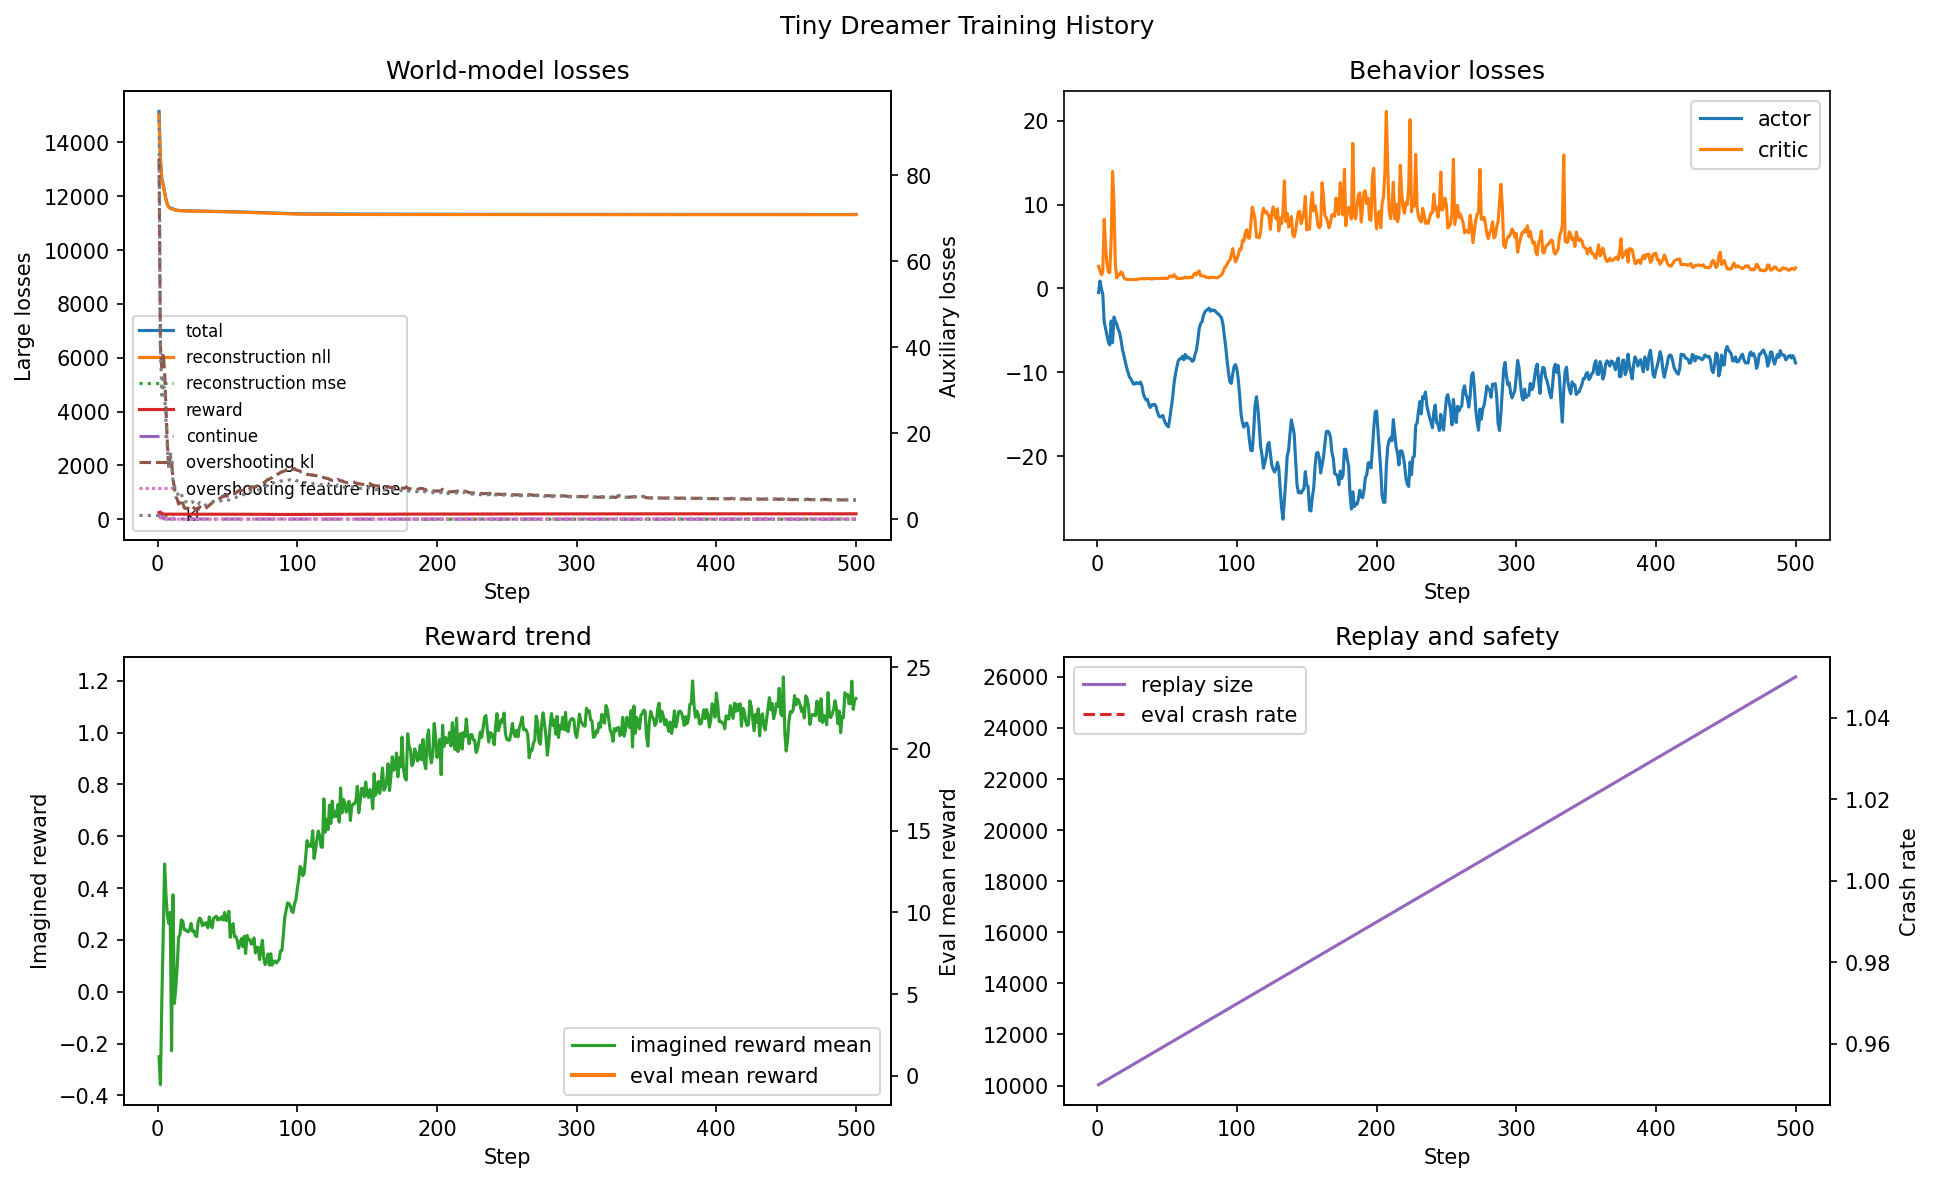

{'analysis_summary': {'best_eval_mean_reward': 24.418187554114983,
  'best_eval_reward_step': 275,
  'best_imagined_reward_mean': 1.21484375,
  'best_imagined_reward_step': 448,
  'best_world_model_step': 496,
  'best_world_model_total_loss': 11320.685302734375,
  'largest_replay_size': 26000,
  'largest_replay_step': 500,
  'last_metrics': {'behavior/actor_entropy': -0.7424993366003036,
   'behavior/actor_loss': -8.888426303863525,
   'behavior/critic_loss': 2.4626213014125824,
   'behavior/imagined_reward_mean': 1.1318359375,
   'behavior/imagined_value_mean': 6.2734375,
   'evaluation/crash_rate': 1.0,
   'evaluation/episodes': 10.0,
   'evaluation/mean_reward': 12.707431154581732,
   'evaluation/mean_steps': 18.1,
   'policy_added': 32,
   'replay_size': 26000,
   'step': 500,
   'warm_start_added': 0,
   'world_model/continue_loss': 0.017067236709408462,
   'world_model/kl_loss': 4.4833152294158936,
   'world_model/kl_loss_raw': 4.4833152294158936,
   'world_model/observation_log_

In [7]:
from IPython.display import Image, display
import csv
import importlib
import json
import tiny_dreamer_highway.evaluation.training_analysis as training_analysis

training_analysis = importlib.reload(training_analysis)
export_training_history_artifacts = training_analysis.export_training_history_artifacts

analysis_outputs = export_training_history_artifacts(
    training_summary.log_dir / 'cycle_metrics.csv',
    RUN_ARTIFACT_ROOT / 'analysis',
    prefix=RUN_NAME,
)

display(Image(filename=str(analysis_outputs['curves'])))
analysis_summary = json.loads(analysis_outputs['summary'].read_text(encoding='utf-8'))
with (training_summary.log_dir / 'cycle_metrics.csv').open('r', encoding='utf-8', newline='') as handle:
    metric_rows = list(csv.DictReader(handle))
latest_metrics_row = metric_rows[-1]
{
    'analysis_summary': analysis_summary,
    'phase4_metrics': {
        'world_model/reconstruction_loss': latest_metrics_row.get('world_model/reconstruction_loss'),
        'world_model/reconstruction_mse': latest_metrics_row.get('world_model/reconstruction_mse'),
        'world_model/observation_log_prob': latest_metrics_row.get('world_model/observation_log_prob'),
        'world_model/overshooting_kl_loss': latest_metrics_row.get('world_model/overshooting_kl_loss'),
        'world_model/overshooting_feature_mse': latest_metrics_row.get('world_model/overshooting_feature_mse'),
        'evaluation/mean_reward': latest_metrics_row.get('evaluation/mean_reward'),
        'evaluation/crash_rate': latest_metrics_row.get('evaluation/crash_rate'),
    },
}

## Agent Driving Demo

Record agent-driving GIFs using the trained policy from this run. These show the actor driving in the real highway-env.

Using demo recorder from: tiny_dreamer_highway.evaluation.policy_rollout
[demo] episode 1/10 | steps=30 | reward=28.52 | CRASH | saved iter21_low_smoothing_ep01.gif
[demo] episode 2/10 | steps=7 | reward=-0.45 | CRASH | saved iter21_low_smoothing_ep02.gif
[demo] episode 3/10 | steps=121 | reward=119.67 | OK | saved iter21_low_smoothing_ep03.gif
[demo] episode 4/10 | steps=32 | reward=32.69 | CRASH | saved iter21_low_smoothing_ep04.gif
[demo] episode 5/10 | steps=8 | reward=2.62 | CRASH | saved iter21_low_smoothing_ep05.gif
[demo] episode 6/10 | steps=6 | reward=-0.77 | CRASH | saved iter21_low_smoothing_ep06.gif
[demo] episode 7/10 | steps=26 | reward=22.96 | CRASH | saved iter21_low_smoothing_ep07.gif
[demo] episode 8/10 | steps=14 | reward=5.69 | CRASH | saved iter21_low_smoothing_ep08.gif
[demo] episode 9/10 | steps=30 | reward=28.51 | CRASH | saved iter21_low_smoothing_ep09.gif
[demo] episode 10/10 | steps=18 | reward=11.77 | CRASH | saved iter21_low_smoothing_ep10.gif
[demo] done 

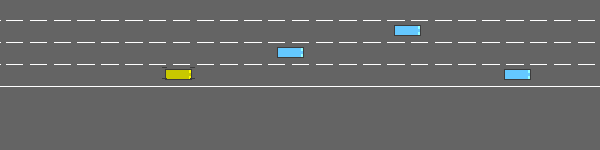


iter21_low_smoothing_ep02.gif


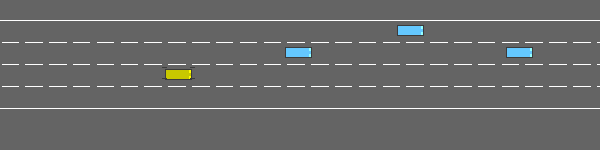


iter21_low_smoothing_ep03.gif


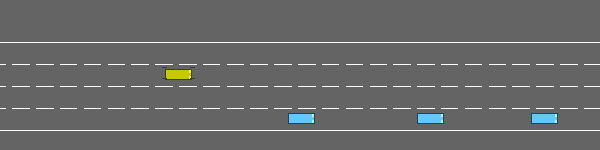


iter21_low_smoothing_ep04.gif


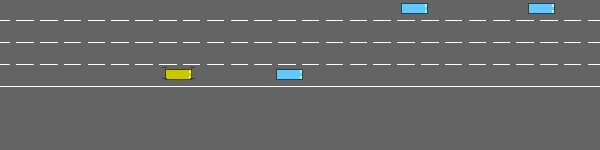


iter21_low_smoothing_ep05.gif


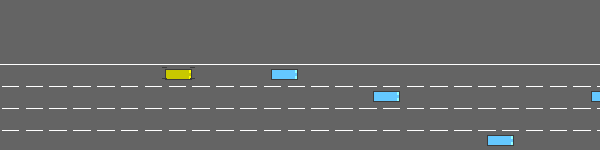


iter21_low_smoothing_ep06.gif


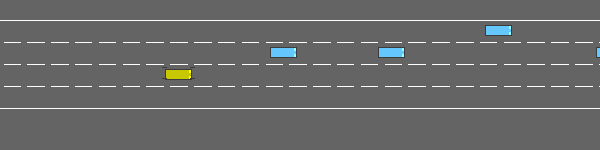


iter21_low_smoothing_ep07.gif


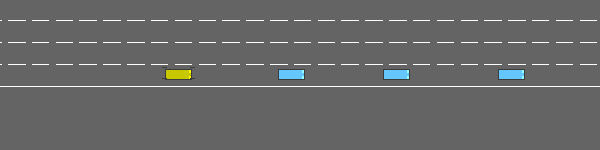


iter21_low_smoothing_ep08.gif


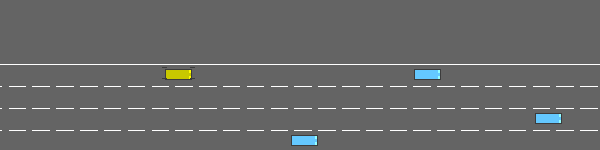


iter21_low_smoothing_ep09.gif


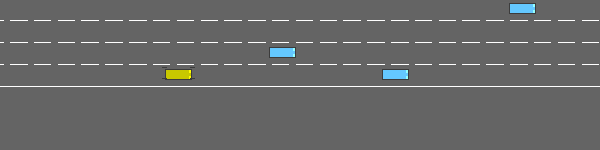


iter21_low_smoothing_ep10.gif


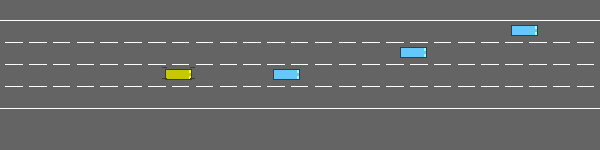

In [8]:
from IPython.display import Image, display
import importlib
import tiny_dreamer_highway.evaluation as evaluation_pkg

try:
    evaluation_pkg = importlib.reload(evaluation_pkg)
    record_demo_videos = evaluation_pkg.record_demo_videos
except (AttributeError, ImportError):
    from tiny_dreamer_highway.evaluation.policy_rollout import record_demo_videos

print('Using demo recorder from:', record_demo_videos.__module__)

demo_outputs = record_demo_videos(
    config,
    checkpoint_path=training_summary.latest_checkpoint,
    output_dir=RUN_ARTIFACT_ROOT / 'demo_videos',
    num_episodes=10,
    max_steps=1000,
    fps=15,
    seed=config.seed,
    prefix=RUN_NAME,
    device=config.device,
)

for gif_path in demo_outputs.video_paths:
    print(f'\n{gif_path.name}')
    display(Image(filename=str(gif_path)))